# Data Generation

In [3]:
%matplotlib inline
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

dim_theta = 10
data_num = 1000
scale = .1

theta_true = np.ones((dim_theta,1))
print('True theta:', theta_true.reshape(-1))

A = np.random.uniform(low=-1.0, high=1.0, size=(data_num,dim_theta))
y_data = A @ theta_true + np.random.normal(loc=0.0, scale=scale, size=(data_num, 1))

A_test = np.random.uniform(low=-1.0, high=1.0, size=(50, dim_theta))
y_test = A_test @ theta_true + np.random.normal(loc=0.0, scale=scale, size=(50, 1))

True theta: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Solving for the exact mean squared loss (solving Ax = b)

In [4]:
print('Not implemented.')

'''
Hints:
1. See the least squares solution to Ax = b (when it is covered in lecture).

2. Use Numpy functions like Numpy's linear algebra functions to solve for x in Ax = b.
In fact, the linear algebra module is already imported with ```import numpy.linalg as la```.

3. Use the defined variable A in Ax = b. Use y_data as b. Use theta_pred as x.
'''
theta_pred = la.inv(A.T @ A) @ A.T @ y_data # TODO: Implement the analytical solution

print('Empirical theta', theta_pred.reshape(-1))

Not implemented.
Empirical theta [1.00348039 1.00480806 1.00395789 0.99946241 0.99370008 1.00347826
 0.99832959 1.00945978 1.00616794 1.00013429]


# SGD Variants Noisy Function

In [5]:
batch_size = 1
max_iter = 1000
lr = 0.001
theta_init = np.random.random((10,1)) * 0.1

In [11]:
def noisy_val_grad(theta_hat, data_, label_, deg_=2.):
    gradient = np.zeros_like(theta_hat)
    loss = 0

    for i in range(data_.shape[0]):
        x_ = data_[i, :].reshape(-1,1)
        y_ = label_[i, 0]
        err = np.sum(x_ * theta_hat) - y_

        #print('Not implemented.')

        '''
        Hints:
        1. Find the gradient and loss for each data point x_.
        2. For grad, you need err, deg_, and x_.
        3. For l, you need err and deg_ only.
        4. Checkout the writeup for more hints.
        '''
        grad = deg_ * np.abs(err) ** (deg_-1) * np.sign(err) * x_ # TODO: Implement the analytical gradient
        l = np.abs(err) ** deg_ # TODO: Implement the loss function

        loss += l / data_.shape[0]
        gradient += grad / data_.shape[0]

    return loss, gradient

# Running SGD Variants

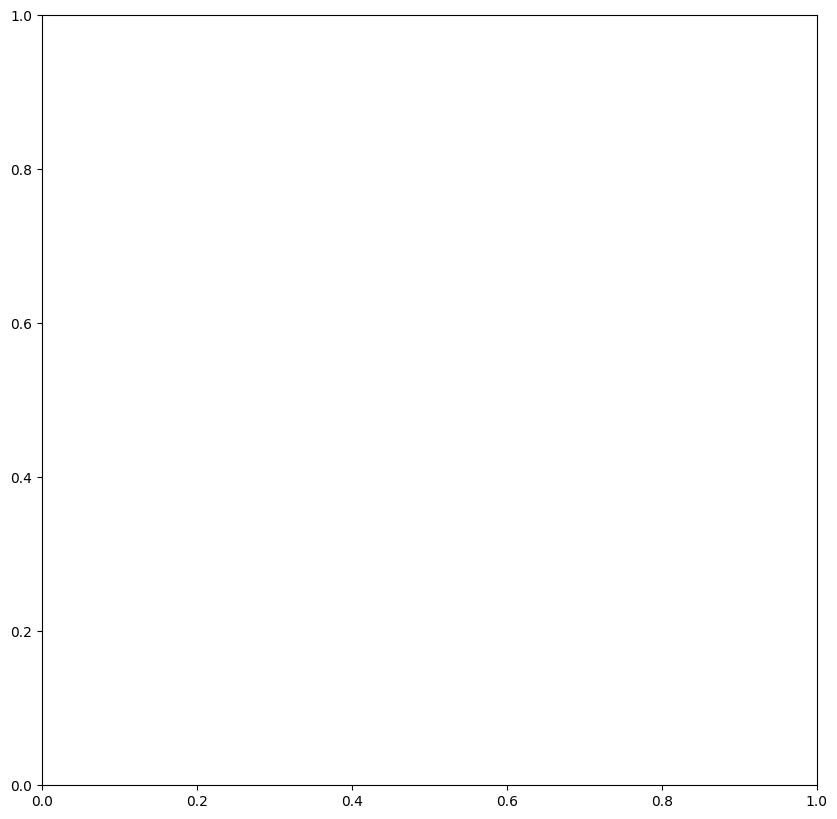

In [24]:
#@title Parameters
deg_ = 2. #@param {type: "number"}
num_rep = 50 #@param {type: "integer"}
max_iter = 1000 #@param {type: "integer"}
fig, ax = plt.subplots(figsize=(10,10))
best_vals = {}
test_exp_interval = 50 #@param {type: "integer"}
grad_artificial_normal_noise_scale = 0. #@param {type: "number"}

adam 0
adam 20
adam 40
adam 60
adam 80
adam 100
adam 120
adam 140
adam 160
adam 180
sgd 0
sgd 20
sgd 40
sgd 60
sgd 80
sgd 100
sgd 120
sgd 140
sgd 160
sgd 180
adagrad 0
adagrad 20
adagrad 40
adagrad 60
adagrad 80
adagrad 100
adagrad 120
adagrad 140
adagrad 160
adagrad 180
adam 0
adam 20
adam 40
adam 60
adam 80
adam 100
adam 120
adam 140
adam 160
adam 180
sgd 0
sgd 20
sgd 40
sgd 60
sgd 80
sgd 100
sgd 120
sgd 140
sgd 160
sgd 180
adagrad 0
adagrad 20
adagrad 40
adagrad 60
adagrad 80
adagrad 100
adagrad 120
adagrad 140
adagrad 160
adagrad 180
adam 0
adam 20
adam 40
adam 60
adam 80
adam 100
adam 120
adam 140
adam 160
adam 180
sgd 0
sgd 20
sgd 40
sgd 60
sgd 80
sgd 100
sgd 120
sgd 140
sgd 160
sgd 180
adagrad 0
adagrad 20
adagrad 40
adagrad 60
adagrad 80
adagrad 100
adagrad 120
adagrad 140
adagrad 160
adagrad 180
adam 0
adam 20
adam 40
adam 60
adam 80
adam 100
adam 120
adam 140
adam 160
adam 180
sgd 0
sgd 20
sgd 40
sgd 60
sgd 80
sgd 100
sgd 120
sgd 140
sgd 160
sgd 180
adagrad 0
adagrad 20
adagr

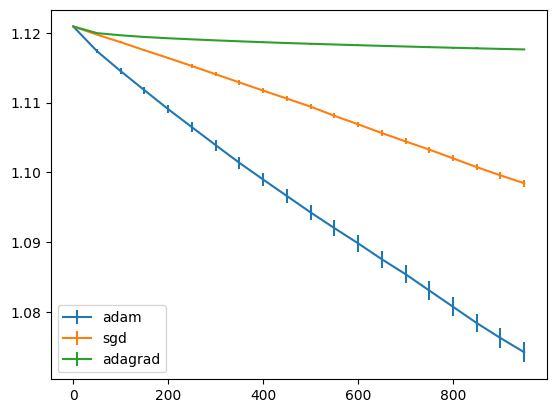

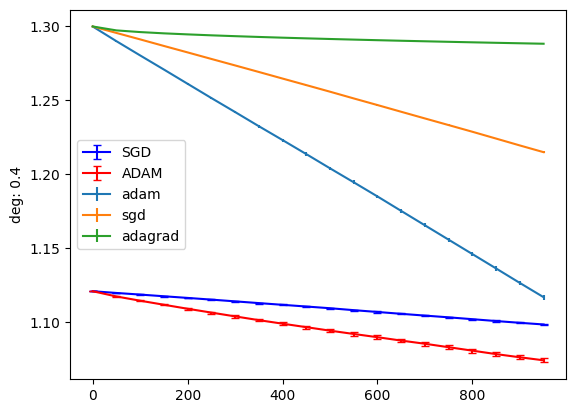

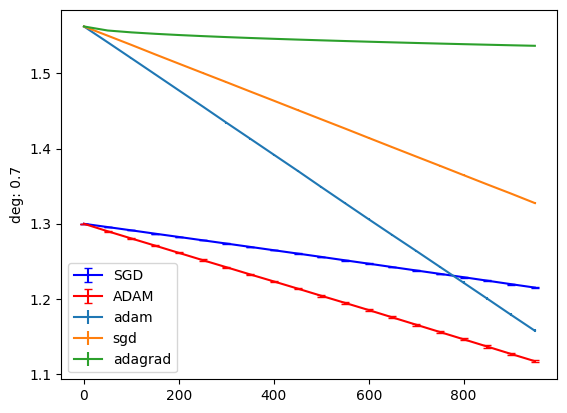

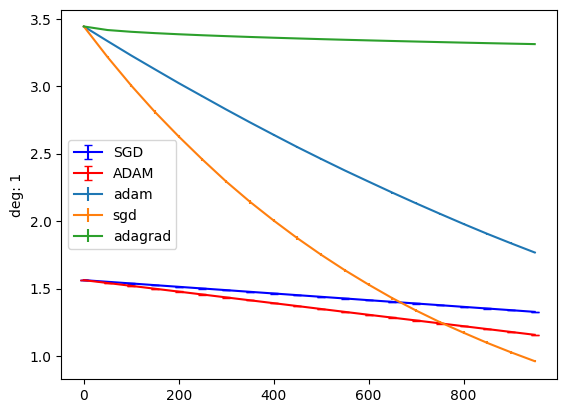

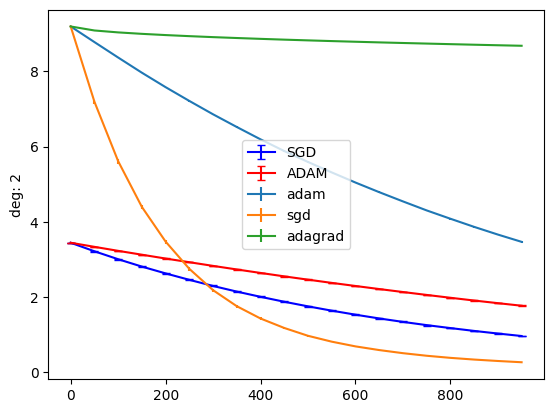

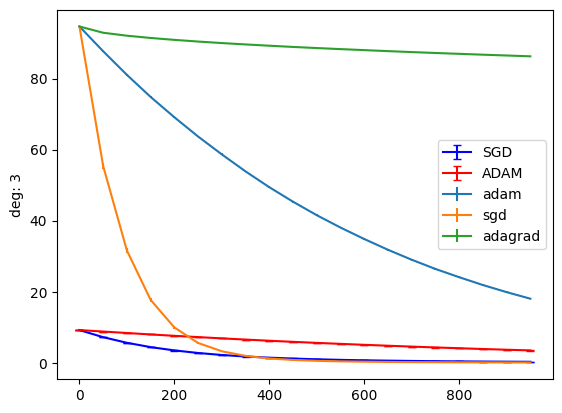

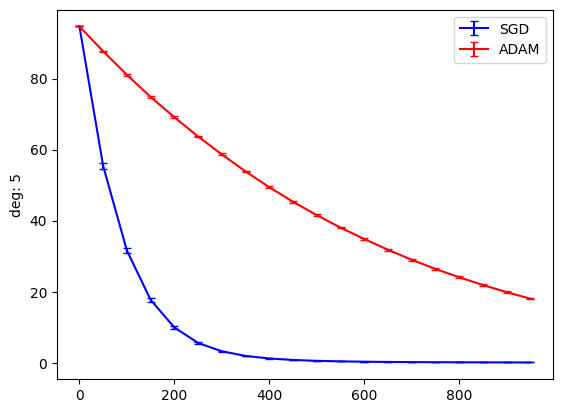

In [40]:
for deg in (0.4, 0.7, 1, 2, 3, 5):
    results = {}

    for method_idx, method in enumerate(['adam', 'sgd', 'adagrad']):
        test_loss_mat = []
        train_loss_mat = []

        for replicate in range(num_rep):
            if replicate % 20 == 0:
                print(method, replicate)

            if method == 'adam':
                beta_1 = 0.9
                beta_2 = 0.999
                m = np.zeros_like(theta_init) # TODO: Initialize parameters
                v = np.zeros_like(theta_init)
                epsilon = 1e-8

            if method == 'adagrad':
                #print('Adagrad Not implemented.')
                epsilon = 1e-8 # TODO: Initialize parameters
                squared_sum = np.zeros_like(theta_init)

            theta_hat = theta_init.copy()
            test_loss_list = []
            train_loss_list = []

            for t in range(max_iter):
                idx = np.random.choice(data_num, batch_size) # Split data
                train_loss, gradient = noisy_val_grad(theta_hat, A[idx,:], y_data[idx,:], deg_=deg)
                artificial_grad_noise = np.random.randn(10, 1) * grad_artificial_normal_noise_scale + np.sign(np.random.random((10, 1)) - 0.5) * 0.
                gradient = gradient + artificial_grad_noise

                # --- Gradient Clipping ---
                clip_threshold = 30.0
                norm = np.linalg.norm(gradient)
                if norm > clip_threshold:
                    gradient = gradient * (clip_threshold / norm)
                # -------------------------

                train_loss_list.append(train_loss)

                if t % test_exp_interval == 0:
                    test_loss, _ = noisy_val_grad(theta_hat, A_test[:,:], y_test[:,:], deg_=deg)
                    test_loss_list.append(test_loss)

                if method == 'adam':
                    m = beta_1 * m + (1-beta_1) * gradient
                    v = beta_2 * v + (1-beta_2) * gradient **2
                    m_hat = m/ (1-(beta_1)**(t+1))
                    v_hat = v/ (1-(beta_2)**(t+1))
                    theta_hat = theta_hat - lr * m_hat / (np.sqrt(v_hat) + epsilon)

                elif method == 'adagrad':
                    squared_sum = squared_sum + (gradient ** 2) # TODO: Implement Adagrad
                    theta_hat = theta_hat - lr * (gradient / (np.sqrt(squared_sum) + epsilon))

                elif method == 'sgd':
                    theta_hat = theta_hat - lr * gradient

            test_loss_mat.append(test_loss_list)
            train_loss_mat.append(train_loss_list)

        x_axis = np.arange(max_iter)[::test_exp_interval]
        test_loss_np = np.array(test_loss_mat)   # shape: (num_rep, n_eval_points)
        results[method] = test_loss_np

        test_loss_mean = np.mean(test_loss_np, axis = 0)
        test_loss_se = np.std(test_loss_np, axis = 0)/ (np.sqrt(num_rep))

        plt.errorbar(x_axis, test_loss_mean, yerr=2.5*test_loss_se, label=method)
        plt.legend()
        best_vals[method] = min(test_loss_mean)

    plt.figure()
    for method, color in [('sgd', 'blue'), ('adam', 'red')]:
        arr = results[method]
        mean = arr.mean(axis=0)
        se   = arr.std(axis=0) / np.sqrt(num_rep)

        plt.ylabel(f'deg: {deg}')
        plt.errorbar(x_axis, mean, yerr=2.5*se, label=method.upper(),
                    color=color, capsize=3, elinewidth=1.5)

        plt.legend()

In [ ]:
best_vals = { k: int(v * 1000) / 1000. for k,v in best_vals.items() } # A weird way to round numbers
plt.title(f'Test Loss \n(objective degree: {deg_},  best values: {best_vals})')
plt.ylabel('Test Loss')
plt.legend()
plt.xlabel('Updates')